## Teen Phone Addiction Dataset- Exploratory Data Analysis
### OBJECTIVE- We try to analyse the dataset given: phone addiction in teens, and related factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display 

In [2]:
df_raw = pd.read_csv("teen_phone_addiction_dataset.csv")
df= df_raw.copy()
print("Loaded:", "teen_phone_addiction_dataset.csv")

Loaded: teen_phone_addiction_dataset.csv


--------------------------------

### Display and inspect the dataset

In [3]:
df_raw.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [4]:
print("Shape:", df_raw.shape)
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

Shape: (3000, 25)
Rows: 3000
Columns: 25


In [5]:
df_raw.info()
display(df_raw.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   str    
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   str    
 4   Location                3000 non-null   str    
 5   School_Grade            3000 non-null   str    
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   int64  
 15

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,3000.0,NaN,NaN,NaN,1500.5,866.169729,1.0,750.75,1500.5,2250.25,3000.0
Name,3000,2933,Michael Garcia,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,3000.0,NaN,NaN,NaN,15.969667,1.989489,13.0,14.0,16.0,18.0,19.0
Gender,3000,3,Male,1016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,3000,2726,North Michael,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
School_Grade,3000,6,12th,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily_Usage_Hours,3000.0,NaN,NaN,NaN,5.020667,1.956501,0.0,3.7,5.0,6.4,11.5
Sleep_Hours,3000.0,NaN,NaN,NaN,6.489767,1.490713,3.0,5.5,6.5,7.5,10.0
Academic_Performance,3000.0,NaN,NaN,NaN,74.947333,14.684156,50.0,62.0,75.0,88.0,100.0
Social_Interactions,3000.0,NaN,NaN,NaN,5.097667,3.139333,0.0,2.0,5.0,8.0,10.0


In [6]:
df_raw.describe(include=["object","str"])

,Name,Gender,Location,School_Grade,Phone_Usage_Purpose
count,3000,3000,3000,3000,3000
unique,2933,3,2726,6,5
top,Michael Garcia,Male,North Michael,12th,Browsing
freq,3,1016,6,529,627


-----------------------------------------------

### Data cleaning, outlier detection and outlier handling.
We will look for missing values, duplicate rows, and zeros in measurement columns. 

In [7]:
missing = df_raw.isna().sum().sort_values(ascending=False)
print("Missing values per column:")
display(missing[missing > 0] if missing.any() else pd.Series({"No missing values": 0}))
print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate IDs:", df_raw["ID"].duplicated().sum() if "ID" in df_raw else "ID column not present")


Missing values per column:


No missing values    0
dtype: int64

Exact duplicate rows: 0
Duplicate IDs: 0


In [8]:
df = df_raw.copy()

outlier_cols = [
    "Daily_Usage_Hours",
    "Exercise_Hours",
    "Screen_Time_Before_Bed",
    "Weekend_Usage_Hours"
]

for col in outlier_cols:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_mask = (df_raw[col] < lower_limit) | (df_raw[col] > upper_limit)
    median_value = df_raw[col].median()

    df.loc[outlier_mask, col] = median_value

    print(f"{col}: replaced {outlier_mask.sum()} outlier values with median {median_value}")

Daily_Usage_Hours: replaced 10 outlier values with median 5.0
Exercise_Hours: replaced 17 outlier values with median 1.0
Screen_Time_Before_Bed: replaced 3 outlier values with median 1.0
Weekend_Usage_Hours: replaced 17 outlier values with median 6.0


noting numerical v/s categorical data.

In [9]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include=["object","str"]).columns
print("Numerical Columns:")
print(list(numerical_columns))
print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['ID', 'Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level']

Categorical Columns:
['Name', 'Gender', 'Location', 'School_Grade', 'Phone_Usage_Purpose']


---------------------------------------------

### Checking invalid values.
Values outside a range are flagged for review, not silently deleted.

In [10]:
range_rules = {
    "Age": (13, 19), "Daily_Usage_Hours": (0, 24), "Sleep_Hours": (0, 24), "Academic_Performance": (0, 100), "Social_Interactions": (0, 10),
    "Exercise_Hours": (0, 24), "Anxiety_Level": (1, 10), "Depression_Level": (1, 10), "Self_Esteem": (1, 10),
    "Parental_Control": (0, 1), "Screen_Time_Before_Bed": (0, 24), "Phone_Checks_Per_Day": (0, None), "Apps_Used_Daily": (0, None),
    "Time_on_Social_Media": (0, 24), "Time_on_Gaming": (0, 24), "Time_on_Education": (0, 24), "Family_Communication": (1, 10), 
    "Weekend_Usage_Hours": (0, 24), "Addiction_Level": (1, 10)
}
invalid = {}
for col, (low, high) in range_rules.items():
    if col in df.columns:
        bad = df[col] < low
        if high is not None:
            bad |= df[col] > high
        if bad.any():
            invalid[col] = df.loc[bad, col].tolist()
print("Out-of-range values:", invalid if invalid else "None found under these screening rules")

Out-of-range values: None found under these screening rules


----------------------------------------------------------

### histograms and boxplots

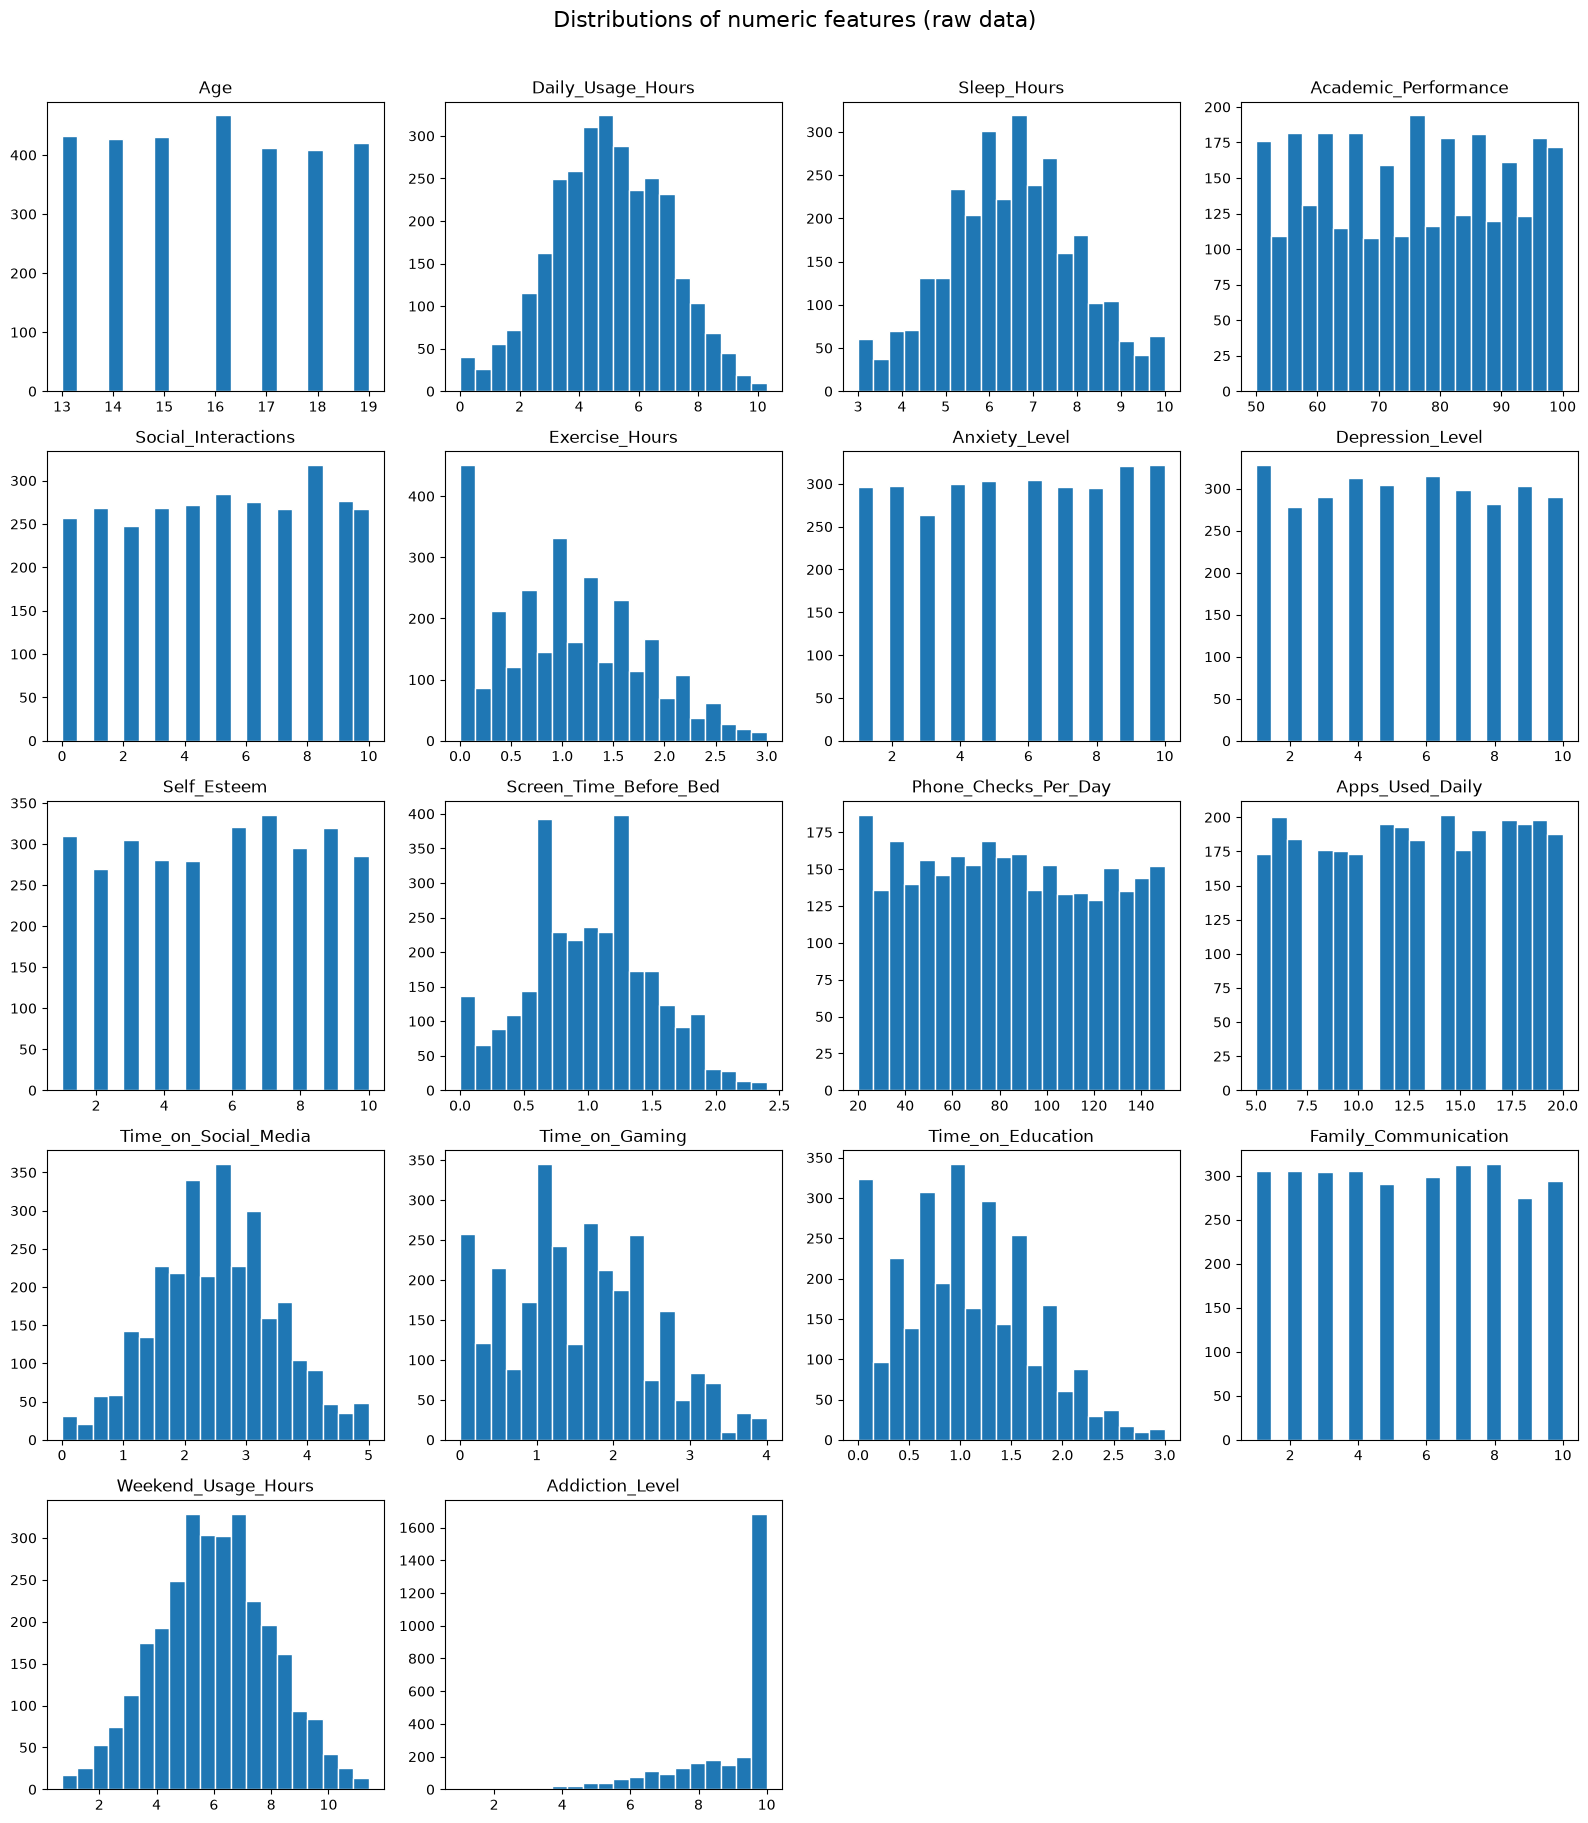

In [11]:
analysis_cols = [
    c for c in df.select_dtypes(include="number").columns
    if c not in ["ID", "Parental_Control"]
]
plot_cols = [c for c in analysis_cols if c in df.columns]
axes = df[plot_cols].hist(figsize=(16, 18), bins=20, edgecolor="white", grid=False)
plt.suptitle("Distributions of numeric features (raw data)", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

1. Age: Ages 13-19 are represented in fairly similar numbers.
2. Daily usage: Most values cluster around 4-6 hours. very low and very high daily-use values are less common.
3. Sleep: Most values cluster around 6-7.5 hours, with fewer observations at the extremes.
4. Exercise: Values are concentrated at lower hours and get less as exercise time increases.
5. Weekend usage: Most values are around 5-8 hours.
6. Social media, gaming, and education time: Their distributions differ, but the chart alone doesn’t show whether those times are related to addiction scores.
7. Addiction level: Scores pile up at 10, the maximum. This ceiling effect means the score has limited ability to distinguish people at the high end, so interpret relationships involving it cautiously.
8. Rating-style variables such as anxiety, depression, self-esteem, and family communication have roughly similar counts across their values; the chart doesn’t suggest a strong concentration at one score.

-------------------------------------------------------

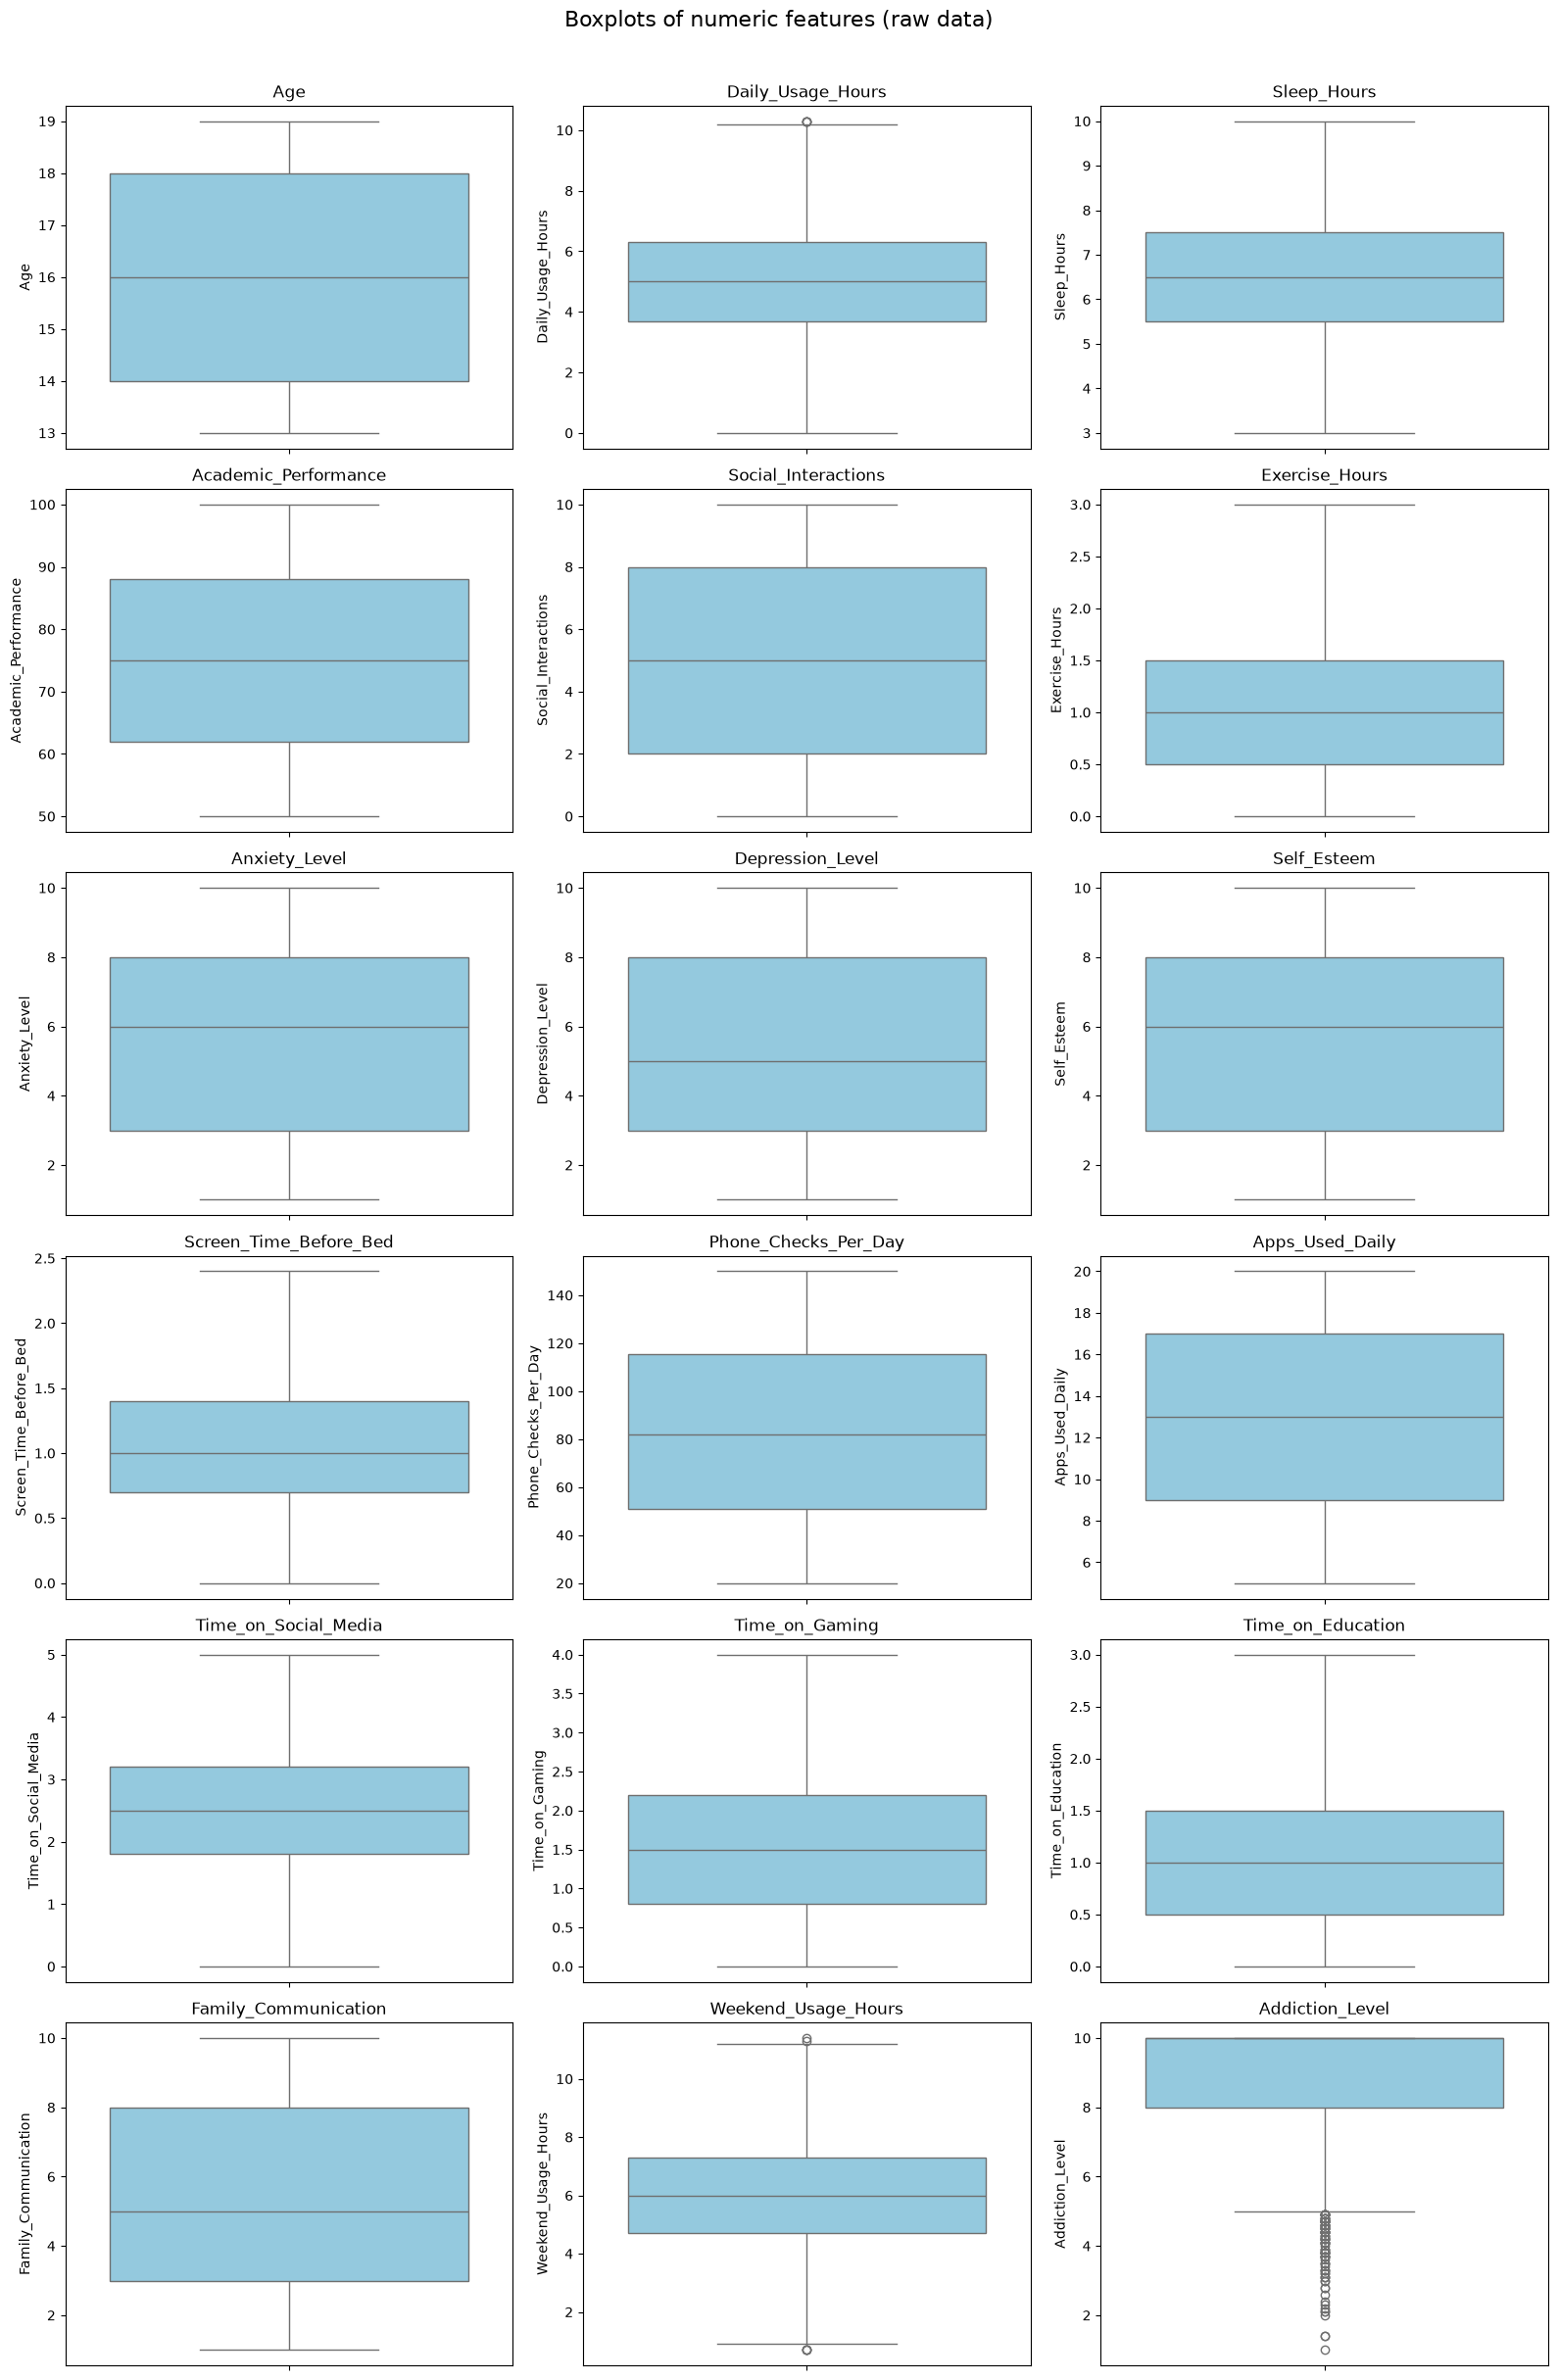

In [12]:
rows = int(np.ceil(len(plot_cols) / 3))
fig, axes = plt.subplots(rows, 3, figsize=(16, 4 * rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, plot_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
for ax in axes[len(plot_cols):]: ax.remove()
fig.suptitle("Boxplots of numeric features (raw data)", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

1. Daily phone use: Median is about 5 hours. Most values are roughly 3.7-6.4 hours, with a few unusually high observations.
2. Sleep: Median is about 6.5 hours; the middle half is around 5.5-7.5 hours.
3. Exercise: Median is about 1 hour. Most values are below 1.5 hours, with a small number of higher values flagged as outliers.
4. Weekend phone use: Median is about 6 hours, with a few high and low outliers.
5. Addiction_Level: Median is 10, and the middle half is also concentrated near 8-10. Many lower scores appear as outliers because scores cluster at the maximum. This ceiling effect can make comparisons harder.
6. Phone checks, apps, social interactions, and rating scores have fairly broad spreads; there aren’t prominent outliers in most of these plots.

---------------------------------------------------------------

### Pie charts for categorical / binned values

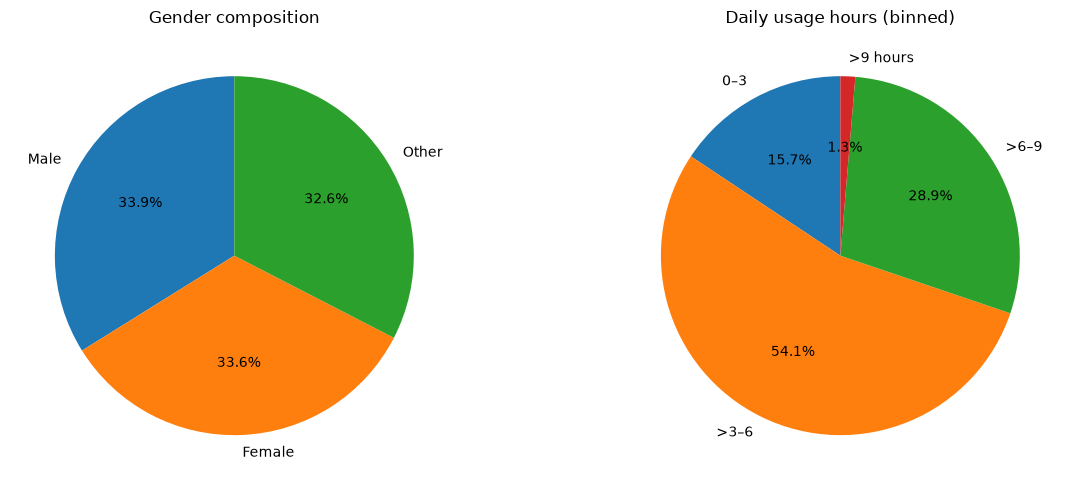

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df["Gender"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[0], startangle=90)
axes[0].set_title("Gender composition"); axes[0].set_ylabel("")
usage_bins = pd.cut(df["Daily_Usage_Hours"], bins=[-0.01, 3, 6, 9, 24], labels=["0–3", ">3–6", ">6–9", ">9 hours"])
usage_bins.value_counts(sort=False).plot.pie(autopct="%1.1f%%", ax=axes[1], startangle=90)
axes[1].set_title("Daily usage hours (binned)"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

- Gender composition: The dataset is nearly evenly split: Male 33.9%, Female 33.6%, and Other 32.6%. Gender representation is balanced overall.
- Daily usage: Most teenagers report more than 3 to 6 hours of daily phone use (53.8%). 28.9% use their phones for more than 6 to 9 hours, 15.7% for 0-3 hours, and 1.7% for over 9 hours.

-----------------------------------------------------------------------

## Categorical distributions: bar graphs

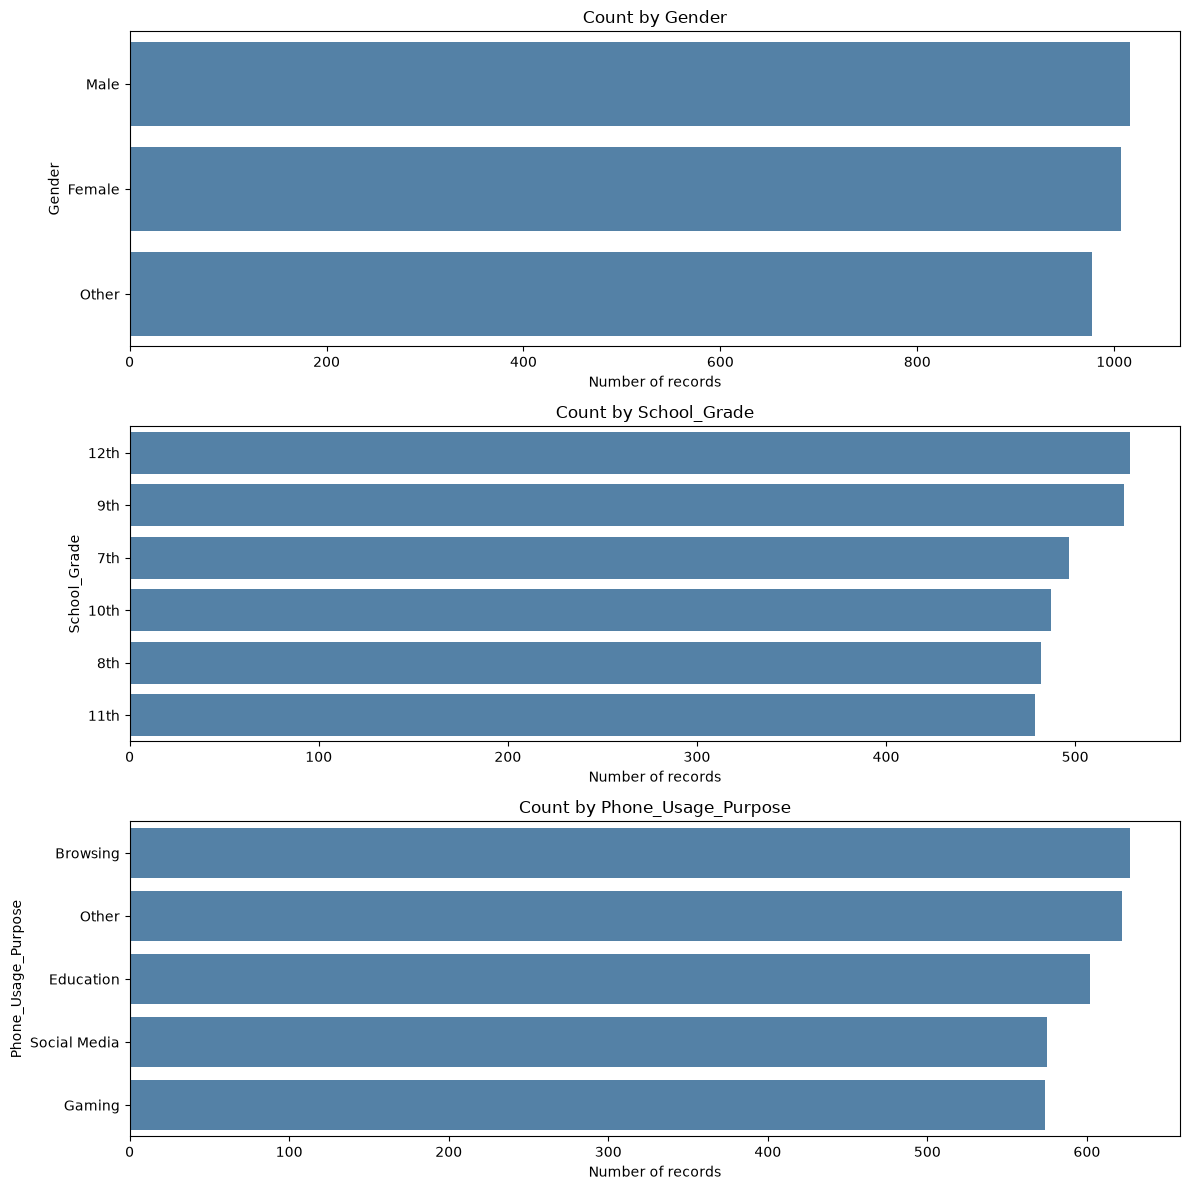

In [14]:
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
cat_plot_cols = [c for c in cat_cols if c not in ["Name", "Location"]]
fig, axes = plt.subplots(len(cat_plot_cols), 1, figsize=(12, 4 * len(cat_plot_cols)))
if len(cat_plot_cols) == 1: axes = [axes]
for ax, col in zip(axes, cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="steelblue")
    ax.set_title(f"Count by {col}"); ax.set_xlabel("Number of records")
plt.tight_layout(); plt.show()

- Gender: The groups are nearly balanced, with about 1,000 records each. This means no gender group dominates the sample.
- School grade: Each grade is also represented fairly evenly, with roughly 480-530 records. 12th and 9th grades have slightly more records, 11th has slightly fewer.
- Phone-usage purpose: The categories are similar in size too. Browsing and “Other” are a little more common, while Gaming and Social Media are a little less common.

------------------------------------------------

### Addiction level across categories: boxplots

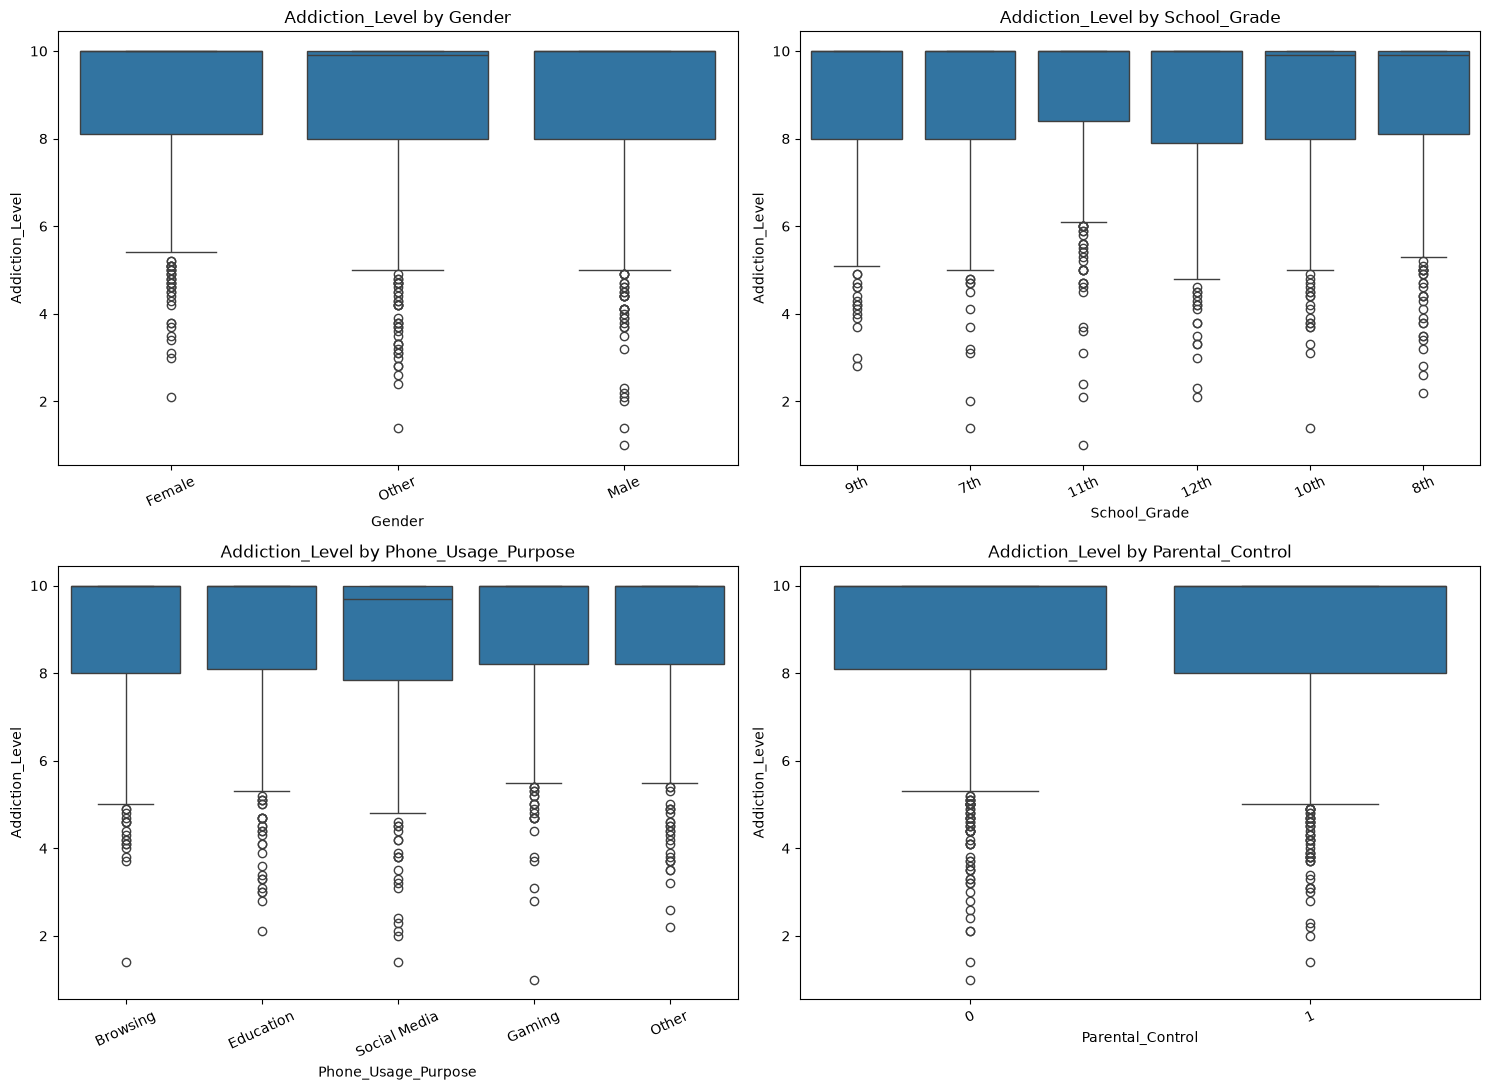

In [15]:
group_cols = [c for c in ["Gender", "School_Grade", "Phone_Usage_Purpose", "Parental_Control"] if c in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, col in zip(axes.flat, group_cols):
    sns.boxplot(data=df, x=col, y="Addiction_Level", ax=ax)
    ax.set_title(f"Addiction_Level by {col}"); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

- Gender: female, male, and other groups have very similar medians and spreads.
- School grade: scores look broadly similar across grades; no grade clearly stands apart.
- Phone-usage purpose: the distributions for browsing, education, social media, gaming, and other are also quite alike.
- Parental control: both groups show similar score distributions.

-------------------------

### Relationships between numeric features: correlation heatmap

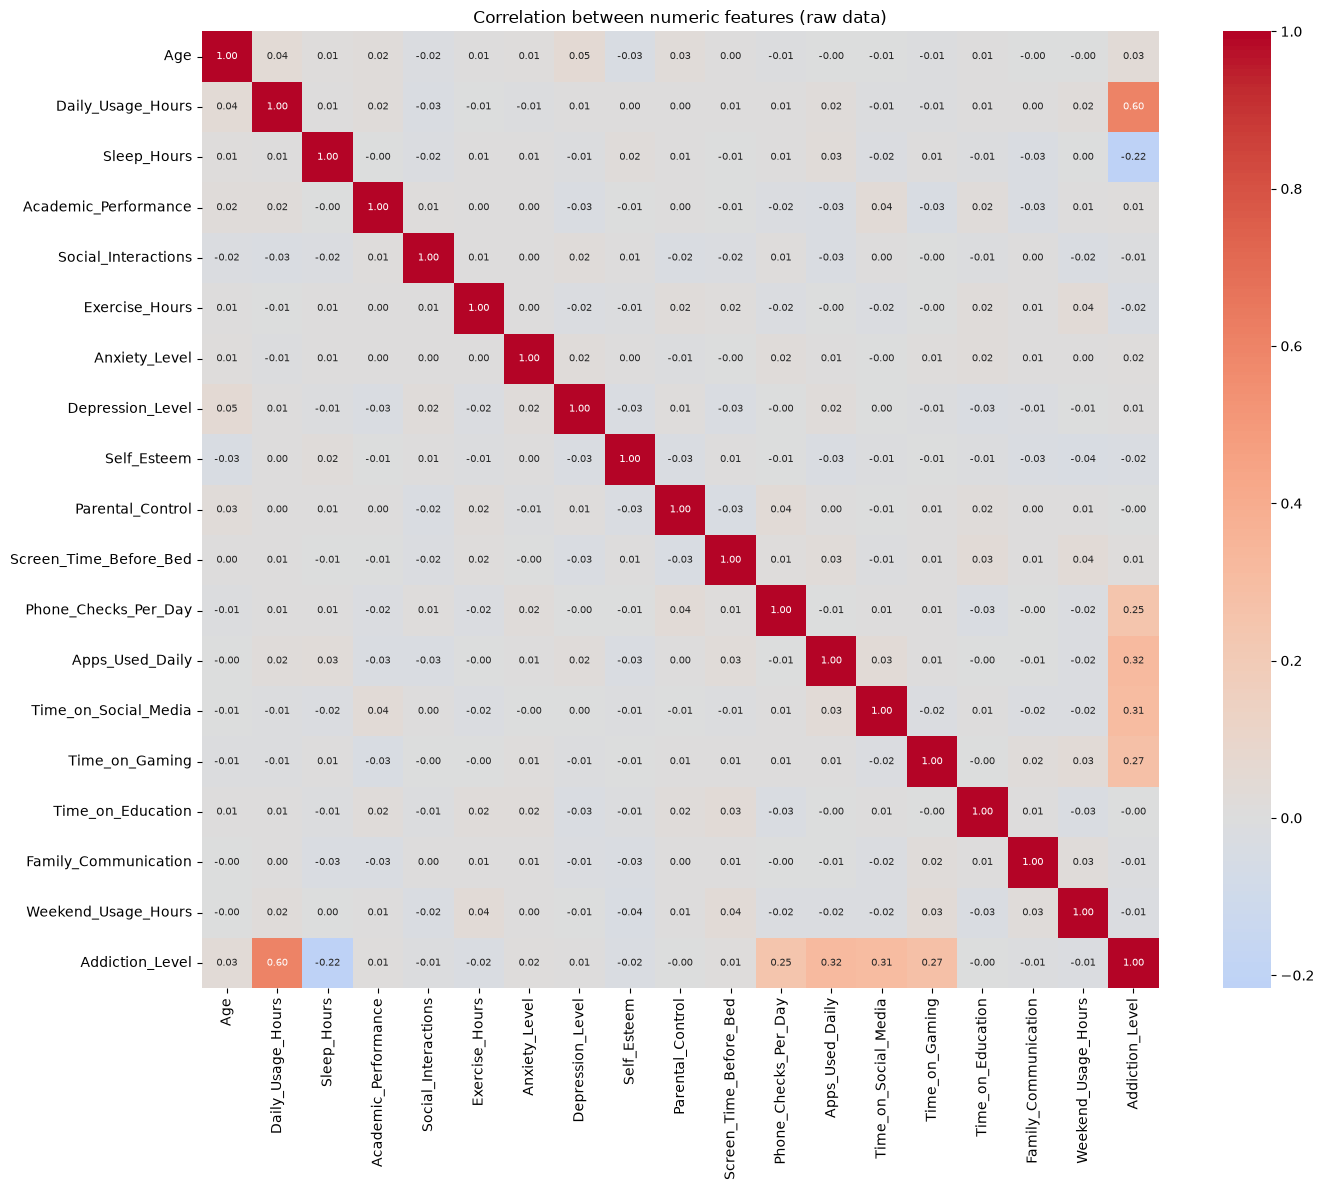

Correlations with Addiction_Level:


,Pearson r
Daily_Usage_Hours,0.602891
Apps_Used_Daily,0.319287
Time_on_Social_Media,0.306578
Time_on_Gaming,0.273060
Phone_Checks_Per_Day,0.246342
Age,0.031306
Anxiety_Level,0.016005
Screen_Time_Before_Bed,0.013896
Academic_Performance,0.012264
Depression_Level,0.008491


In [16]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr_cols = [c for c in numeric_cols if c != "ID"]
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True, annot_kws={"size": 7})
plt.title("Correlation between numeric features (raw data)")
plt.tight_layout(); plt.show()
print("Correlations with Addiction_Level:")
display(corr["Addiction_Level"].drop("Addiction_Level").sort_values(ascending=False).to_frame("Pearson r"))

1. Daily_Usage_Hours: +0.60 - the clearest relationship in this chart. More daily phone use tends to go with a higher addiction score.
2. Apps_Used_Daily: +0.32, Time_on_Social_Media: +0.31, Time_on_Gaming: +0.27, and Phone_Checks_Per_Day: +0.25 -weaker positive relationships.
3. Sleep_Hours: -0.22 - a weak negative relationship: more sleep tends to go with a slightly lower addiction score.
4. Most other features are close to zero, so this chart shows little linear relationship between them and the score.

------------------------

### Other useful views

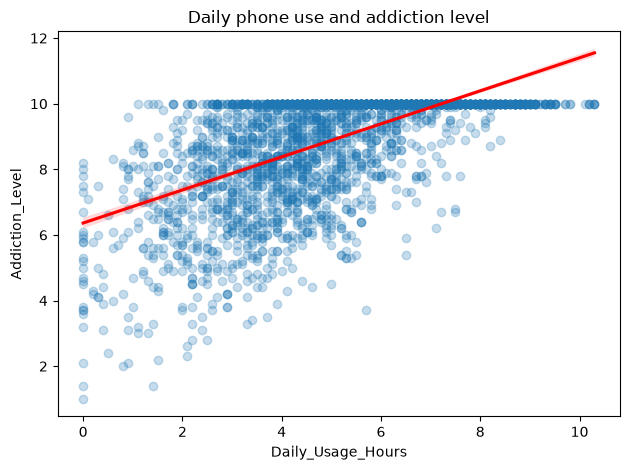

In [17]:
sns.regplot(data=df, x="Daily_Usage_Hours", y="Addiction_Level", scatter_kws={"alpha": 0.25}, line_kws={"color": "red"})
plt.title("Daily phone use and addiction level")
plt.tight_layout()
plt.show()


- The plot shows a positive association: higher daily phone use tends to occur with higher Addiction_Level scores, as indicated by the upward red trend line.
- Many scores are at the maximum of 10, creating a ceiling effect.

---------------------

### Main findings from this file

In [18]:
print(f"Rows: {len(df):,}; columns: {df.shape[1]}")
print("Missing cells:", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))
print("Mean daily phone use (hours):", round(df["Daily_Usage_Hours"].mean(), 2))
print("Median daily phone use (hours):", round(df["Daily_Usage_Hours"].median(), 2))
print("Mean sleep (hours):", round(df["Sleep_Hours"].mean(), 2))
print("Median Addiction_Level:", round(df["Addiction_Level"].median(), 2))
print("Addiction_Level >= 8 share (%):", round((df["Addiction_Level"] >= 8).mean() * 100, 1))
print("Highest positive correlations with Addiction_Level:")
display(corr["Addiction_Level"].drop("Addiction_Level").sort_values(ascending=False).head(5).round(2).to_frame("Pearson r"))
print("Most negative correlations with Addiction_Level:")
display(corr["Addiction_Level"].drop("Addiction_Level").sort_values().head(5).round(2).to_frame("Pearson r"))


Rows: 3,000; columns: 25
Missing cells: 0
Exact duplicate rows: 0
Mean daily phone use (hours): 5.0
Median daily phone use (hours): 5.0
Mean sleep (hours): 6.49
Median Addiction_Level: 10.0
Addiction_Level >= 8 share (%): 76.4
Highest positive correlations with Addiction_Level:


,Pearson r
Daily_Usage_Hours,0.60
Apps_Used_Daily,0.32
Time_on_Social_Media,0.31
Time_on_Gaming,0.27
Phone_Checks_Per_Day,0.25


Most negative correlations with Addiction_Level:


,Pearson r
Sleep_Hours,-0.22
Self_Esteem,-0.02
Exercise_Hours,-0.02
Weekend_Usage_Hours,-0.01
Social_Interactions,-0.01
